# MIMIC-CXR Data Exploration

## Import library

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Thiết lập đường dẫn gốc tới thư mục MIMIC_CXR của bạn
# Sửa lại đường dẫn này cho khớp với máy của bạn
DATA_DIR = r"C:\Users\lebat\Documents\Github\xbone-net\data\MIMIC_CXR"

IMG_DIR = os.path.join(DATA_DIR, "imgs")
REPORT_DIR = os.path.join(DATA_DIR, "reports")
CHEXPERT_CSV = os.path.join(DATA_DIR, "mimic-cxr-2.0.0-chexpert.csv")
SPLIT_CSV = os.path.join(DATA_DIR, "mimic-cxr-2.0.0-split.csv")

# Cấu hình hiển thị đồ thị
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

## Load data

Số lượng ảnh (DICOMs): 377110
Số lượng lần chụp (Studies): 227827

Phân bố dữ liệu Train/Val/Test:
split
train       368960
test          5159
validate      2991
Name: count, dtype: int64


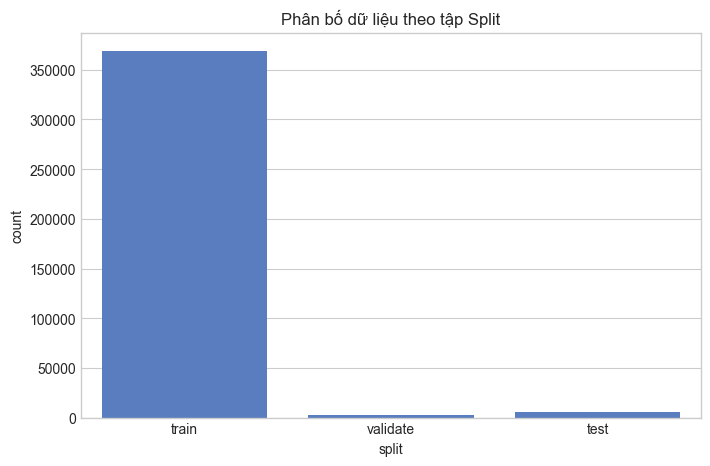

In [2]:
# 1. Load data
df_chexpert = pd.read_csv(CHEXPERT_CSV)
df_split = pd.read_csv(SPLIT_CSV)

print(f"Số lượng ảnh (DICOMs): {len(df_split)}")
print(f"Số lượng lần chụp (Studies): {len(df_chexpert)}")

# 2. Merge data dựa trên subject_id và study_id
df_merged = pd.merge(df_split, df_chexpert, on=["subject_id", "study_id"], how="left")

# 3. Phân tích số lượng mẫu trong từng tập (Train/Val/Test)
print("\nPhân bố dữ liệu Train/Val/Test:")
print(df_merged['split'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df_merged, x='split', order=['train', 'validate', 'test'])
plt.title("Phân bố dữ liệu theo tập Split")
plt.show()

## Labels exploration

C:\Users\lebat\AppData\Local\Temp\ipykernel_19228\3599248335.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_counts.values, y=positive_counts.index, palette="viridis")


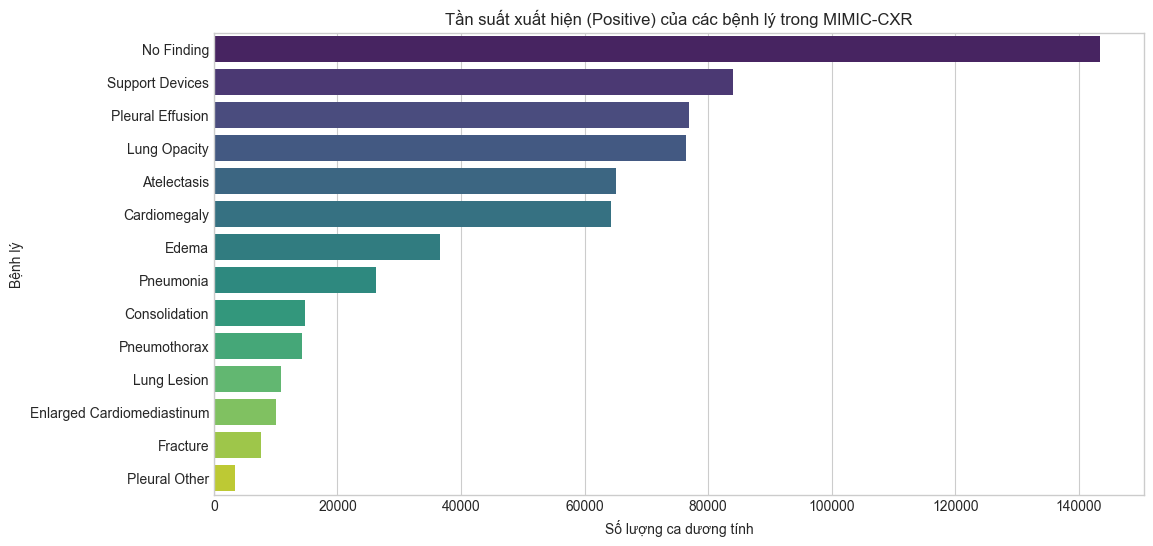


Top các bệnh lý có nhãn Uncertain (-1.0) nhiều nhất:
Pneumonia                     29150
Edema                         19409
Atelectasis                   15536
Enlarged Cardiomediastinum    12585
Pleural Effusion               8587
dtype: int64


In [3]:
# Danh sách 14 loại bệnh lý từ CheXpert
pathologies = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 
    'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 
    'Lung Opacity', 'No Finding', 'Pleural Effusion', 
    'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

# Đếm số lượng ca Dương tính (1.0) cho mỗi bệnh lý
positive_counts = (df_merged[pathologies] == 1.0).sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=positive_counts.values, y=positive_counts.index, palette="viridis")
plt.title("Tần suất xuất hiện (Positive) của các bệnh lý trong MIMIC-CXR")
plt.xlabel("Số lượng ca dương tính")
plt.ylabel("Bệnh lý")
plt.show()

# Kiểm tra vấn đề "Uncertain Labels" (-1.0)
uncertain_counts = (df_merged[pathologies] == -1.0).sum().sort_values(ascending=False)
print("\nTop các bệnh lý có nhãn Uncertain (-1.0) nhiều nhất:")
print(uncertain_counts.head())

## Image-report pair samples

=== THÔNG TIN BỆNH NHÂN ===
Subject ID: 16094649 | Study ID: 56617413 | Split: train
Bệnh lý (Positive): Cardiomegaly, Lung Opacity, Support Devices

=== RADIOLOGY REPORT ===
                                 FINAL REPORT
 EXAMINATION:  CHEST (PORTABLE AP)
 
 INDICATION:  ___ year old woman with ET tube/variceal bleed  // placemetn of ET
 tube      placemetn of ET tube
 
 IMPRESSION: 
 
 The No previous images.  Endotracheal tube tip lies approximately 2.5 cm above
 the carina. Nasogastric tube extends to the distal stomach. There are very low
 lung volumes which enhance the transverse diameter of the heart. . 
 Retrocardiac opacification is consistent with volume loss in the left lower
 lobe. No definite pulmonary vascular congestion.



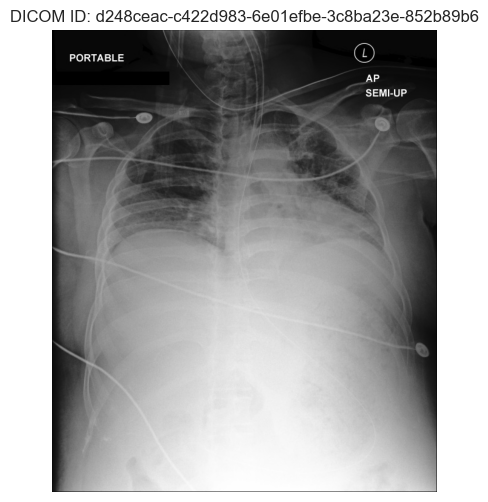

In [7]:
import random

# Chọn ngẫu nhiên một mẫu từ tập merged
sample = df_merged.sample(1).iloc[0]

subject_id = f"p{str(sample['subject_id'])[:2]}/p{sample['subject_id']}"
study_id = f"s{sample['study_id']}"
dicom_id = sample['dicom_id']

# Đường dẫn (MIMIC-CXR tổ chức theo p[2_số_đầu]/p[ID]/s[ID]/[DICOM].jpg)
# Giả định ảnh của bạn là định dạng .jpg (thường dùng sau khi convert từ DICOM)
img_path = os.path.join(IMG_DIR, subject_id, study_id, f"{dicom_id}.jpg")
report_path = os.path.join(REPORT_DIR, subject_id, f"{study_id}.txt")

# 1. Trích xuất nhãn
positive_labels = [path for path in pathologies if sample[path] == 1.0]

# 2. Đọc Report
report_text = "Không tìm thấy file report."
if os.path.exists(report_path):
    with open(report_path, 'r') as f:
        report_text = f.read()

# 3. Hiển thị
print(f"=== THÔNG TIN BỆNH NHÂN ===")
print(f"Subject ID: {sample['subject_id']} | Study ID: {sample['study_id']} | Split: {sample['split']}")
print(f"Bệnh lý (Positive): {', '.join(positive_labels) if positive_labels else 'Không có nhãn dương tính'}\n")

print(f"=== RADIOLOGY REPORT ===")
# In ra phần FINDINGS và IMPRESSION của report (thường nằm ở cuối)
print(report_text[:1000] + "..." if len(report_text) > 1000 else report_text)

# 4. Hiển thị Ảnh
if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"DICOM ID: {dicom_id}")
    plt.axis('off')
    plt.show()
else:
    print(f"\n[Lỗi] Không tìm thấy ảnh tại: {img_path}")
    print("Vui lòng kiểm tra lại cấu trúc thư mục imgs của bạn xem có đúng định dạng pXX/pXXXX/sXXXX/XXXX.jpg không.")